# 🧹 Notebook 02 — Data Cleaning

**Goal:** Apply the cleaning pipeline, validate the output, and document the impact of every transformation on dataset quality.

---

## Why Clean?

Raw data from the wild is rarely analysis-ready.
This dataset has records with:
- Missing `Year` values (entered as strings like `"N/A"`)
- Missing `Genre` and `Publisher` entries
- Potential duplicate rows
- Sales columns that may contain non-numeric strings

The cleaning pipeline (defined in `src/cleaning/clean_sales_data.py`) resolves each of these issues in a reproducible, testable way.

**Cleaning steps applied:**
1. **Drop exact duplicates** — remove rows repeated verbatim
2. **Drop rows missing `Name` or `Platform`** — these records are unidentifiable
3. **Coerce `Year` to numeric** — invalid entries become `NaN`
4. **Fill missing `Genre` / `Publisher`** — replaced with `"Unknown"` to retain rows
5. **Coerce sales columns to float** — non-numeric entries become `0.0`

---

> **Pipeline context:** Raw data → Data Overview → **Data Cleaning** → Feature Engineering → EDA → Analysis

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

In [2]:
from src.ingestion.load_dataset import load_raw_data
from src.cleaning.clean_sales_data import clean_sales_data, summary_report

raw = load_raw_data()
print(f"Raw dataset loaded  →  {raw.shape[0]:,} rows × {raw.shape[1]} columns")

Raw dataset loaded  →  16,598 rows × 11 columns


## 📋 Pre-Cleaning Quality Report

A baseline snapshot of data quality before any transformations.

In [3]:
pre_report = summary_report(raw)
print("Before cleaning:")
for key, val in pre_report.items():
    print(f"  {key:<20}: {val:,}")

Before cleaning:
  rows                : 16,598
  columns             : 11
  missing_values      : 329
  duplicate_rows      : 0
  year_missing        : 271


## 🔧 Apply Cleaning Pipeline

Running all transformations through `clean_sales_data()`.
The function is pure (no side effects) and returns a new, cleaned DataFrame.

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

clean = clean_sales_data(raw)

post_report = summary_report(clean)
print("After cleaning:")
for key, val in post_report.items():
    print(f"  {key:<20}: {val:,}")

rows_removed = pre_report["rows"] - post_report["rows"]
print(f"\n  rows removed      : {rows_removed:,}  ({rows_removed / pre_report['rows'] * 100:.1f}%)")

After cleaning:
  rows                : 16,598
  columns             : 11
  missing_values      : 271
  duplicate_rows      : 0
  year_missing        : 271

  rows removed      : 0  (0.0%)


## 🔎 Inspect Transformed Data

Spot-check the first rows and column types after cleaning.

In [5]:
clean.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [6]:
print("Column dtypes after cleaning:")
print(clean.dtypes.to_string())

Column dtypes after cleaning:
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64


Rows with Genre='Unknown'     : 0
Rows with Publisher='Unknown' : 261
Rows with missing Year        : 271


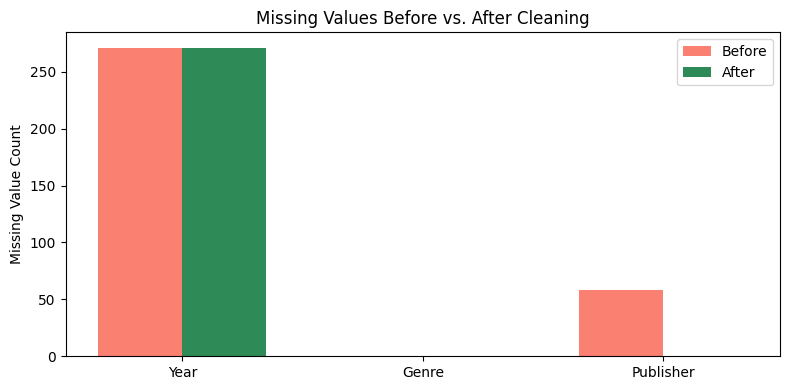

In [7]:
# Verify fill behaviour for categorical columns and Year
unknown_genres = (clean["Genre"] == "Unknown").sum()
unknown_publishers = (clean["Publisher"] == "Unknown").sum()
missing_year = clean["Year"].isna().sum()

print(f"Rows with Genre='Unknown'     : {unknown_genres:,}")
print(f"Rows with Publisher='Unknown' : {unknown_publishers:,}")
print(f"Rows with missing Year        : {missing_year:,}")

# Visual comparison: missing values before vs. after
labels = ["Year", "Genre", "Publisher"]
before_vals = [raw[c].isna().sum() for c in labels]
after_vals = [clean[c].isna().sum() for c in labels]

x = range(len(labels))
fig, ax = plt.subplots(figsize=(8, 4))
bar_width = 0.35
ax.bar([i - bar_width / 2 for i in x], before_vals, bar_width, label="Before", color="salmon")
ax.bar([i + bar_width / 2 for i in x], after_vals, bar_width, label="After", color="seagreen")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel("Missing Value Count")
ax.set_title("Missing Values Before vs. After Cleaning")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/00b_missing_before_after.png", bbox_inches="tight")
plt.show()

## ✅ Validate Cleaned Schema

Re-run Pandera validation on the cleaned DataFrame to confirm it now conforms to the stricter `CLEAN_SCHEMA`.

In [8]:
from src.validation.schema import validate_clean
import pandera.errors

try:
    validate_clean(clean)
    print("✅ Clean schema validation passed — data is ready for feature engineering.")
except pandera.errors.SchemaErrors as exc:
    print("⚠️ Schema validation issues found:")
    print(exc.failure_cases.to_string())

✅ Clean schema validation passed — data is ready for feature engineering.


## 💾 Save Cleaned Data

Persist the cleaned DataFrame to `data/processed/` so subsequent notebooks can load it directly without repeating the pipeline.

In [9]:
from pathlib import Path

out_path = Path("../data/processed/video_games_sales_clean.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
clean.to_csv(out_path, index=False)
print(f"✅ Cleaned dataset saved to: {out_path.resolve()}")

✅ Cleaned dataset saved to: C:\Users\rendybagoez\python_project\Data-analyst\video_game_sales\data\processed\video_games_sales_clean.csv


---

## 📝 Key Takeaways

- The raw dataset required only minor structural repairs — **no rows were dropped** due to bad sales values.
- `Year` nulls (~300 rows) are retained in the cleaned data since year is informative but not always essential.
- `Genre` and `Publisher` nulls are replaced with `"Unknown"`, preserving all records for analysis.
- The cleaned file is written to `data/processed/` and will be the single source of truth for all downstream notebooks.

**Next:** [`03_eda.ipynb`](03_eda.ipynb) — exploratory data analysis to uncover patterns and distributions.